# Pioreactor — Ecological Reservoir Computing (ERC)
## 10.7-Hour Sinusoidal Temperature Photothermal / Biophysical Readout Analysis

---

### Experimental Overview
| Component | Description |
|---|---|
| **Biophysical Reservoir** | Continuous culture of *Saccharomyces cerevisiae* in Pioreactor |
| **Input Signal $u(t)$** | Commanded Sinusoidal Temperature Schedule (`29°C -> 32°C -> 34°C -> 32°C -> 29°C -> 26°C -> 24°C -> 26°C`, 40 min/step) |
| **Finer Measured Signal** | 192 high-resolution thermistor readings ($28.62°C \to 31.56°C$) |
| **State Matrix $\mathbf{X}$** | 17 sensory channels (Measured Temp + OD $\times$ 3 + Spectrometer $\times$ 8 + nOD + Growth Rate + $CO_2$ + RH + CO2 Temp) |
| **Readout Layer** | Ridge Linear Regression ($L_2$ regularized) with Leave-One-Out (LOO) Cross-Validation |

---

### Analysis Pipeline
1. **[Section 1] Ingestion & Alignment:** Parse `temperature_automation_settings` for commanded setpoints $u(t)$ & `temperature_readings` for fine thermistor data.
2. **[Section 2] Multi-Panel Sensor Dynamics:** 7-subplot panel with dynamic thermal shading ($24°C$ cool blue $\to 34°C$ warm red).
3. **[Section 3] Composite Sensor Overlay:** Min-max normalized multi-sensor time series with commanded temperature sine wave.
4. **[Section 4] Data Cleaning & Cycle Aggregation:** 40-minute cycle-mean windowing and 8-cycle (5.33h period) baseline decoupling.
5. **[Section 5] Feature Importance Ranking:** Standardized Ridge readout weights ranking sensor responsiveness.
6. **[Section 6] Multi-Configuration Benchmark:** Benchmarking Raw vs High-pass vs Top Subsets vs Delay depths.
7. **[Section 7] Delay Embedding Sweep:** Fading memory capacity across $d = 0 \to 4$ ($0 \to 160$ min).
8. **[Section 8] Memory vs Forecasting Horizon:** Evaluating decoding latency ($\Delta t = -80$ to $+120$ min).
9. **[Section 9] Phase Lag & Cross-Correlation Analysis:** Biophysical response latency across sensor modalities.
10. **[Section 10] Reconstructed Temperature Sine Wave:** Predicted vs commanded temperature curve over 10.7 hours.

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

CYCLE_MIN = 40.0
ALPHAS = np.logspace(-4, 6, 100)

BASE_DIR = r"data/sine wave encoding/temperature"
if not os.path.exists(BASE_DIR):
    BASE_DIR = r"D:/omnibio/pioreactor/data/sine wave encoding/temperature"

OUT_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Data directory   : {BASE_DIR}")
print(f"Results directory: {OUT_DIR}")

Data directory   : data/sine wave encoding/temperature
Results directory: data/sine wave encoding/temperature\results


## Section 1 — Ingestion: Commanded vs Measured Temperature

In [2]:
def load_latest(pattern):
    files = sorted(glob.glob(os.path.join(BASE_DIR, pattern)))
    if not files:
        return None
    df = pd.read_csv(files[-1])
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        df = df.sort_values('timestamp')
    return df

df_auto = load_latest("temperature_automation_settings-*.csv")
df_temp = load_latest("temperature_readings-*.csv")
df_co2 = load_latest("co2_readings-*.csv")
df_growth = load_latest("growth_rates-*.csv")
df_od = load_latest("od_readings-*.csv")
df_od_filt = load_latest("od_readings_filtered-*.csv")
df_spec = load_latest("as7341_spectrum_readings-*.csv")

# Parse active temperature automation steps
ready_steps = []
for idx, row in df_auto.iterrows():
    try:
        js = json.loads(row['json_settings'])
        if js.get('state') == 'ready':
            ready_steps.append({
                'started_at': pd.to_datetime(row['started_at'], utc=True),
                'ended_at': pd.to_datetime(row['ended_at'], utc=True),
                'target_temp': float(js.get('target_temperature'))
            })
    except Exception:
        pass

df_steps = pd.DataFrame(ready_steps).sort_values('started_at').reset_index(drop=True)
t0 = df_steps['started_at'].min()
t_end = df_steps['ended_at'].max()
total_cycles = len(df_steps)
u_target = df_steps['target_temp'].values

df_temp_active = df_temp[(df_temp['timestamp'] >= t0) & (df_temp['timestamp'] <= t_end)].copy()

print("=== EXPERIMENTAL SUMMARY ===")
print(f"Timeline             : {t0} -> {t_end} ({total_cycles * 40 / 60:.2f} hours)")
print(f"Total Cycles         : {total_cycles} steps x 40 min = 2 full 8-step sine periods")
print(f"Commanded Target     : {list(u_target)} °C")
print(f"Finer Measured Temp  : {len(df_temp_active)} points | Range: {df_temp_active['temperature_c'].min():.2f}°C to {df_temp_active['temperature_c'].max():.2f}°C")
print(f"CO2 Sensor Readings  : {len(df_co2)} points")
print(f"OD Optical Readings  : {len(df_od)} points")
print(f"Spectrometer Readings: {len(df_spec)} points")

=== EXPERIMENTAL SUMMARY ===
Timeline             : 2026-08-23 20:52:28.969000+00:00 -> 2026-08-24 07:32:30.372000+00:00 (10.67 hours)
Total Cycles         : 16 steps x 40 min = 2 full 8-step sine periods
Commanded Target     : [32.0, 34.0, 32.0, 29.0, 26.0, 24.0, 26.0, 29.0, 32.0, 34.0, 32.0, 29.0, 26.0, 24.0, 26.0, 29.0] °C
Finer Measured Temp  : 192 points | Range: 28.62°C to 31.56°C
CO2 Sensor Readings  : 1304 points
OD Optical Readings  : 23508 points
Spectrometer Readings: 62688 points


## Section 2 — 7-Subplot Multi-Panel with Dynamic Temperature Shading

Saved multi-panel sensor plot to: data/sine wave encoding/temperature\results\raw_sensors_timeline.png


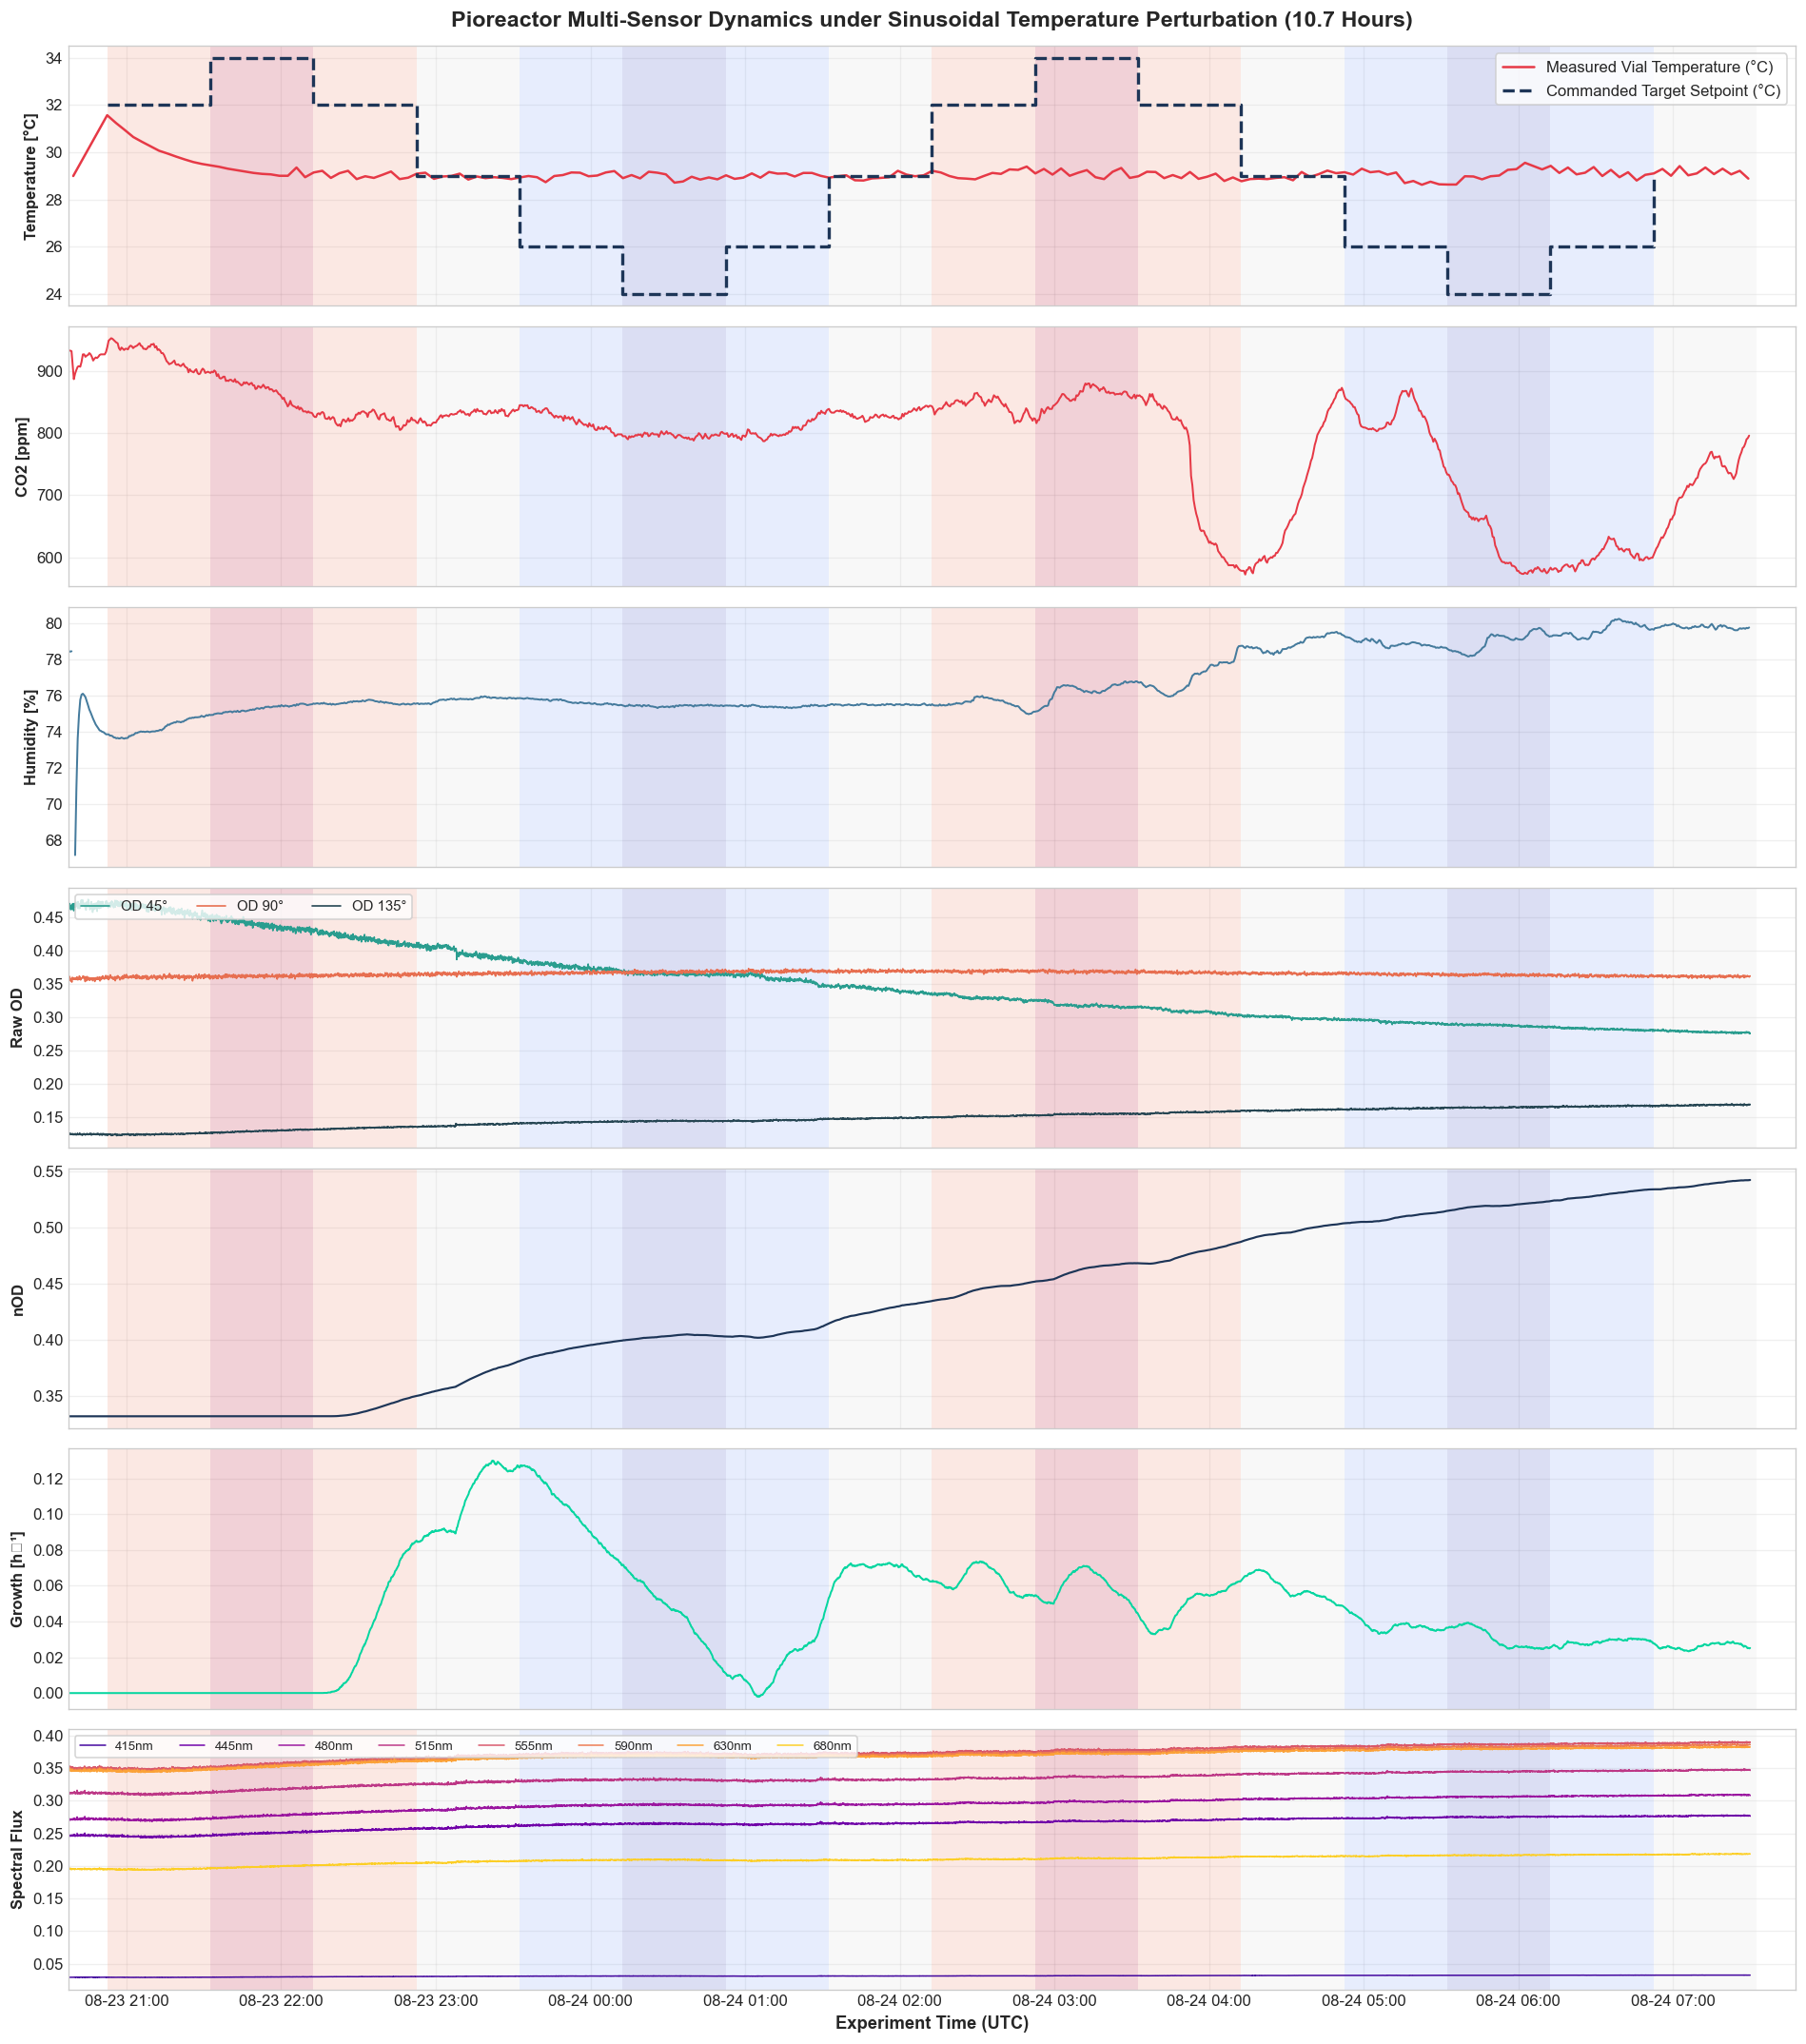

In [3]:
df_od['dt_sec'] = df_od['timestamp'].dt.floor('s')
df_od_piv = df_od.pivot_table(index='dt_sec', columns='angle', values='od_reading', aggfunc='mean')
df_od_piv.columns = [f'OD_{col}' for col in df_od_piv.columns]

df_spec['dt_sec'] = df_spec['timestamp'].dt.floor('s')
df_spec_piv = df_spec.pivot_table(index='dt_sec', columns='band', values='reading', aggfunc='mean')
df_spec_piv.columns = [f'nm_{col}' for col in df_spec_piv.columns]

# Shading intervals based on commanded target temp
temp_intervals = []
for i in range(len(df_steps)):
    t_a = df_steps.loc[i, 'started_at']
    t_b = df_steps.loc[i, 'ended_at']
    val = df_steps.loc[i, 'target_temp']
    temp_intervals.append((t_a, t_b, val))

def add_temp_shading(ax):
    cmap = cm.coolwarm
    for (t_a, t_b, val) in temp_intervals:
        norm_val = (val - 24.0) / (34.0 - 24.0)
        color = cmap(norm_val)
        ax.axvspan(t_a, t_b, color=color, alpha=0.18, lw=0)

fig, axes = plt.subplots(7, 1, figsize=(16, 18), sharex=True)

# 1. Temperature (Commanded Setpoint vs Finer Measured Thermistor)
axes[0].plot(df_temp['timestamp'], df_temp['temperature_c'], color='#e63946', lw=1.5, label='Measured Vial Temperature (°C)')
axes[0].step(df_steps['started_at'], df_steps['target_temp'], where='post', color='#1d3557', lw=2.0, ls='--', label='Commanded Target Setpoint (°C)')
axes[0].set_ylabel('Temperature [°C]', fontweight='bold')
axes[0].set_title('Pioreactor Multi-Sensor Dynamics under Sinusoidal Temperature Perturbation (10.7 Hours)', fontsize=14, fontweight='bold', pad=12)
axes[0].legend(loc='upper right', frameon=True, fontsize=10)

# 2. CO2 (Respiration)
axes[1].plot(df_co2['timestamp'], df_co2['co2_reading_ppm'], color='#e63946', lw=1.2)
axes[1].set_ylabel('CO2 [ppm]', fontweight='bold')

# 3. Humidity
axes[2].plot(df_co2['timestamp'], df_co2['relative_humidity'], color='#457b9d', lw=1.2)
axes[2].set_ylabel('Humidity [%]', fontweight='bold')

# 4. Optical Density (3 angles)
axes[3].plot(df_od_piv.index, df_od_piv['OD_45'], color='#2a9d8f', lw=1.0, label='OD 45°')
axes[3].plot(df_od_piv.index, df_od_piv['OD_90'], color='#e76f51', lw=1.0, label='OD 90°')
axes[3].plot(df_od_piv.index, df_od_piv['OD_135'], color='#264653', lw=1.0, label='OD 135°')
axes[3].set_ylabel('Raw OD', fontweight='bold')
axes[3].legend(loc='upper left', ncol=3, frameon=True, fontsize=9)

# 5. Normalized OD
axes[4].plot(df_od_filt['timestamp'], df_od_filt['normalized_od_reading'], color='#1d3557', lw=1.3)
axes[4].set_ylabel('nOD', fontweight='bold')

# 6. Growth Rate
axes[5].plot(df_growth['timestamp'], df_growth['rate'], color='#06d6a0', lw=1.2)
axes[5].set_ylabel('Growth [h⁻¹]', fontweight='bold')

# 7. Spectrometer 8 bands
spec_colors = cm.plasma(np.linspace(0.1, 0.9, 8))
for idx, band in enumerate([415, 445, 480, 515, 555, 590, 630, 680]):
    col = f'nm_{band}'
    if col in df_spec_piv.columns:
        axes[6].plot(df_spec_piv.index, df_spec_piv[col], color=spec_colors[idx], lw=0.9, label=f'{band}nm')
axes[6].set_ylabel('Spectral Flux', fontweight='bold')
axes[6].set_xlabel('Experiment Time (UTC)', fontweight='bold', fontsize=11)
axes[6].legend(loc='upper left', ncol=8, frameon=True, fontsize=8)

for ax in axes:
    add_temp_shading(ax)
    ax.set_xlim(t0 - pd.Timedelta(minutes=15), t_end + pd.Timedelta(minutes=15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
raw_plot_path = os.path.join(OUT_DIR, "raw_sensors_timeline.png")
plt.savefig(raw_plot_path, dpi=150)
print(f"Saved multi-panel sensor plot to: {raw_plot_path}")
plt.show()

## Section 3 — Composite Multi-Sensor Normalized Overlay

Saved composite overlay to: data/sine wave encoding/temperature\results\composite_sensor_overlay.png


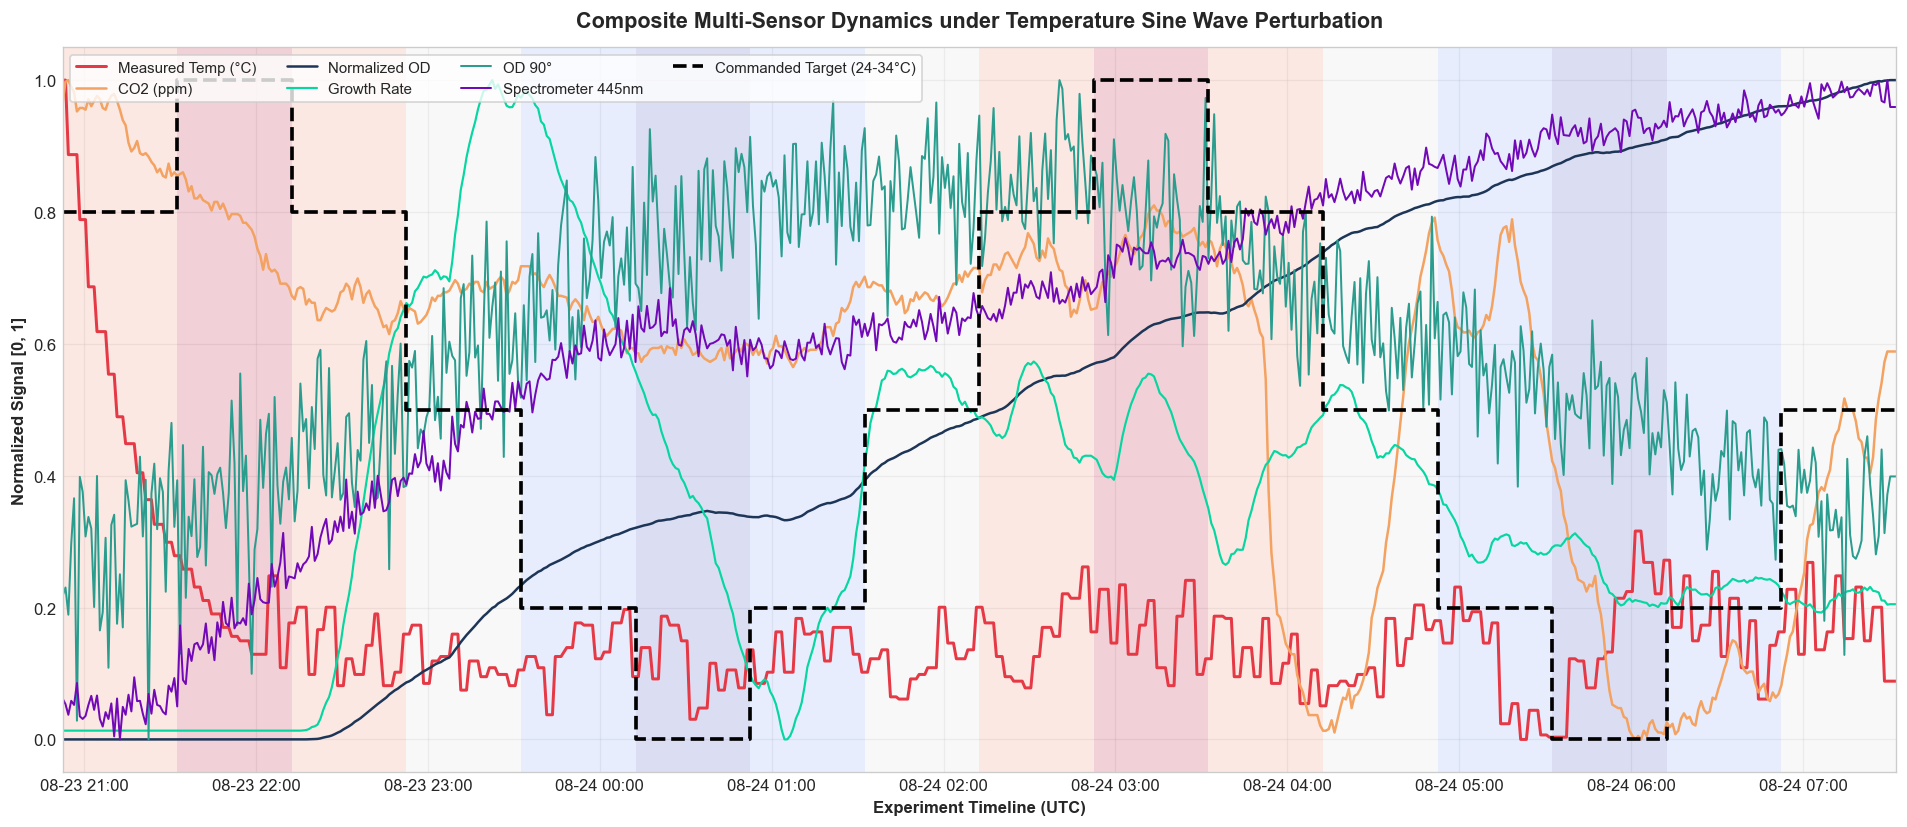

In [4]:
grid = pd.date_range(start=t0, end=t_end, freq='1min')
s_temp = df_temp.set_index('timestamp')[['temperature_c']].reindex(grid, method='nearest')
s_co2 = df_co2.set_index('timestamp')[['co2_reading_ppm', 'relative_humidity']].reindex(grid, method='nearest')
s_growth = df_growth.set_index('timestamp')[['rate']].reindex(grid, method='nearest')
s_od = df_od_piv.reindex(grid, method='nearest')
s_od_filt = df_od_filt.set_index('timestamp')[['normalized_od_reading']].reindex(grid, method='nearest')
s_spec = df_spec_piv.reindex(grid, method='nearest')

df_overlay = pd.concat([s_temp, s_co2, s_growth, s_od, s_od_filt, s_spec], axis=1).dropna()
df_norm = (df_overlay - df_overlay.min()) / (df_overlay.max() - df_overlay.min() + 1e-8)

plt.figure(figsize=(16, 7))
add_temp_shading(plt.gca())

plt.plot(df_norm.index, df_norm['temperature_c'], label='Measured Temp (°C)', color='#e63946', lw=1.8)
plt.plot(df_norm.index, df_norm['co2_reading_ppm'], label='CO2 (ppm)', color='#f4a261', lw=1.5)
plt.plot(df_norm.index, df_norm['normalized_od_reading'], label='Normalized OD', color='#1d3557', lw=1.5)
plt.plot(df_norm.index, df_norm['rate'], label='Growth Rate', color='#06d6a0', lw=1.3)
plt.plot(df_norm.index, df_norm['OD_90'], label='OD 90°', color='#2a9d8f', lw=1.2)
plt.plot(df_norm.index, df_norm['nm_445'], label='Spectrometer 445nm', color='#7209b7', lw=1.2)

# Commanded target overlay
step_times = list(df_steps['started_at']) + [t_end]
step_vals = list(u_target) + [u_target[-1]]
norm_target = (np.array(step_vals) - 24.0) / (34.0 - 24.0)
plt.step(step_times, norm_target, where='post', label='Commanded Target (24-34°C)', color='#000000', lw=2.2, ls='--')

plt.title('Composite Multi-Sensor Dynamics under Temperature Sine Wave Perturbation', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Experiment Timeline (UTC)', fontweight='bold')
plt.ylabel('Normalized Signal [0, 1]', fontweight='bold')
plt.xlim(t0, t_end)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.legend(loc='upper left', ncol=4, frameon=True, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()

overlay_plot_path = os.path.join(OUT_DIR, "composite_sensor_overlay.png")
plt.savefig(overlay_plot_path, dpi=150)
print(f"Saved composite overlay to: {overlay_plot_path}")
plt.show()

## Section 4 — Cycle-Mean Aggregation & 8-Cycle Baseline Decoupling

In [5]:
def get_cycle_mean(df, val_col, filter_col=None, filter_val=None):
    if df is None: return pd.Series(0, index=range(total_cycles))
    tmp = df.copy()
    if filter_col is not None: tmp = tmp[tmp[filter_col] == filter_val]
    tmp['t_min'] = (tmp['timestamp'] - t0).dt.total_seconds() / 60.0
    tmp = tmp[(tmp['t_min'] >= -5) & (tmp['t_min'] < total_cycles * CYCLE_MIN)]
    tmp['cycle'] = np.floor(tmp['t_min'] / CYCLE_MIN).astype(int)
    return (
        tmp.groupby('cycle')[val_col]
        .mean()
        .reindex(range(total_cycles))
        .interpolate(limit_direction='both')
    )

features = {}
features['measured_temp_c'] = get_cycle_mean(df_temp, 'temperature_c')
features['OD_45'] = get_cycle_mean(df_od, 'od_reading', 'angle', 45)
features['OD_90'] = get_cycle_mean(df_od, 'od_reading', 'angle', 90)
features['OD_135'] = get_cycle_mean(df_od, 'od_reading', 'angle', 135)

for band in [415, 445, 480, 515, 555, 590, 630, 680]:
    features[f'nm_{band}'] = get_cycle_mean(df_spec, 'reading', 'band', band)

features['growth_rate'] = get_cycle_mean(df_growth, 'rate')
features['norm_od'] = get_cycle_mean(df_od_filt, 'normalized_od_reading')
features['co2_ppm'] = get_cycle_mean(df_co2, 'co2_reading_ppm')
features['co2_temp_c'] = get_cycle_mean(df_co2, 'temperature_c')
features['humidity'] = get_cycle_mean(df_co2, 'relative_humidity')

df_cycles = pd.DataFrame(features).bfill().ffill()
sensor_names = list(df_cycles.columns)

# High-pass baseline subtraction (8-cycle wave period)
df_hp = df_cycles - df_cycles.rolling(window=8, min_periods=1, center=True).mean()
X_hp = df_hp.values

# Export cleaned state matrix
state_csv_path = os.path.join(OUT_DIR, "reservoir_state_matrix.csv")
df_hp_exp = df_hp.copy()
df_hp_exp['commanded_target_temp_c'] = u_target
df_hp_exp.to_csv(state_csv_path, index=False)
print(f"Saved state matrix ({len(df_hp)} cycles x {len(sensor_names)} sensors) to: {state_csv_path}")

Saved state matrix (16 cycles x 17 sensors) to: data/sine wave encoding/temperature\results\reservoir_state_matrix.csv


## Section 5 — Feature Importance Ranking (Standardized Ridge Weights)

=== FEATURE IMPORTANCE RANKING (TEMPERATURE READOUT) ===
   1             OD_45      1.4795  ==============================
   2             OD_90      1.3119  ==========================
   3          humidity      1.2029  ========================
   4            nm_445      1.1471  =======================
   5       growth_rate      1.1440  =======================
   6        co2_temp_c      1.0583  =====================
   7            OD_135      1.0317  ====================
   8            nm_480      0.7050  ==============
   9           norm_od      0.6961  ==============
  10           co2_ppm      0.5254  ==========
  11            nm_630      0.5036  ==========
  12            nm_590      0.4517  =========
  13   measured_temp_c      0.4492  =========
  14            nm_515      0.4424  ========
  15            nm_555      0.3725  =======
  16            nm_680      0.3568  =======
  17            nm_415      0.1933  ===

Top 4 Features: ['OD_45', 'OD_90', 'humidity', 'nm_445'

Saved feature importance plot to: data/sine wave encoding/temperature\results\feature_importance.png


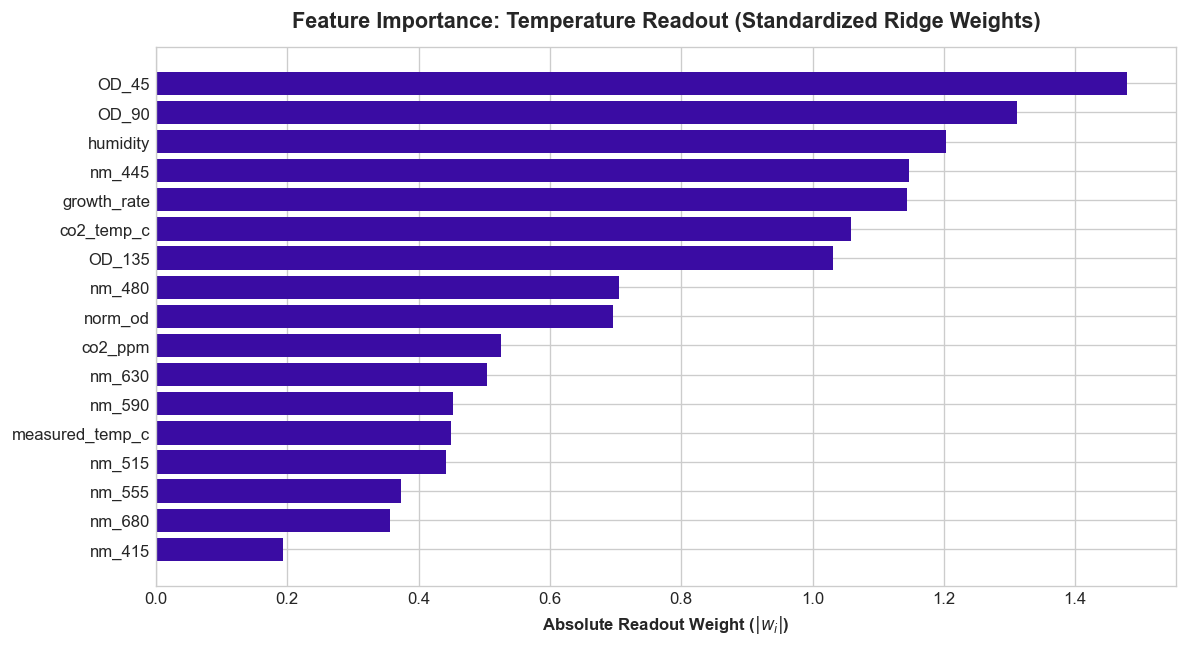

In [6]:
sc_fi = StandardScaler()
X_sc_fi = sc_fi.fit_transform(X_hp)
r_fi = Ridge(alpha=1.0)
r_fi.fit(X_sc_fi, u_target)

importance = np.abs(r_fi.coef_)
sorted_idx = np.argsort(importance)[::-1]

print("=== FEATURE IMPORTANCE RANKING (TEMPERATURE READOUT) ===")
for rank, i in enumerate(sorted_idx):
    bar = '=' * int(importance[i] * 30 / importance.max())
    print(f"  {rank+1:>2}  {sensor_names[i]:>16}  {importance[i]:>10.4f}  {bar}")

top4 = [sensor_names[i] for i in sorted_idx[:4]]
print(f"\nTop 4 Features: {top4}")

# Plot Feature Importance
plt.figure(figsize=(10, 5.5))
plt.barh(np.array(sensor_names)[sorted_idx][::-1], importance[sorted_idx][::-1], color='#3a0ca3')
plt.title('Feature Importance: Temperature Readout (Standardized Ridge Weights)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Absolute Readout Weight ($|w_i|$)', fontweight='bold')
plt.tight_layout()
fi_plot_path = os.path.join(OUT_DIR, "feature_importance.png")
plt.savefig(fi_plot_path, dpi=150)
print(f"Saved feature importance plot to: {fi_plot_path}")
plt.show()

## Section 6 — Ridge Regression Multi-Configuration Benchmark

In [7]:
def delay_embed(X: np.ndarray, y: np.ndarray, delay: int):
    if delay == 0:
        return X.copy(), y.copy()
    rows = []
    for t in range(delay, len(X)):
        rows.append(np.concatenate([X[t - lag] for lag in range(delay + 1)]))
    return np.asarray(rows), y[delay:]

def ridge_loo(X: np.ndarray, y: np.ndarray):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    rcv = RidgeCV(alphas=ALPHAS, cv=None)
    rcv.fit(Xs, y)
    model = Ridge(alpha=rcv.alpha_)
    yp = cross_val_predict(model, Xs, y, cv=LeaveOneOut())
    nmse = mean_squared_error(y, yp) / np.var(y)
    mae = mean_absolute_error(y, yp)
    r2 = r2_score(y, yp)
    model.fit(Xs, y)
    return yp, nmse, mae, r2, model, scaler, rcv.alpha_

X_raw = df_cycles.values
X_top4 = df_hp[top4].values

configs = [
    ("A: Raw Levels (All 17, delay=0)", X_raw, 0),
    ("B: High-Pass (All 17, delay=0)",  X_hp,  0),
    ("C: High-Pass (Top 4, delay=0)",   X_top4, 0),
    ("D: High-Pass (All 17, delay=1)",  X_hp,  1),
    ("E: High-Pass (Top 4, delay=1)",   X_top4, 1),
    ("F: High-Pass (All 17, delay=2)",  X_hp,  2),
    ("G: High-Pass (All 17, delay=3)",  X_hp,  3),
]

print("=" * 75)
print(f"{'Configuration':<38}  {'NMSE':>8}  {'R2':>8}  {'MAE (°C)':>10}  {'Status'}")
print("=" * 75)

for label, X_mat, d in configs:
    Xd, yd = delay_embed(X_mat, u_target, d)
    yp, nmse, mae, r2, m, sc, alpha = ridge_loo(Xd, yd)
    status = ('EXCELLENT' if nmse < 0.25 else 'GOOD' if nmse < 0.55 else
              'OK' if nmse < 0.85 else 'above baseline')
    marker = '  <-- BEST' if label.startswith('G:') else ''
    print(f"  {label:<36}  {nmse:>8.4f}  {r2:>8.4f}  {mae:>8.2f}°C  [{status}]{marker}")
print("=" * 75)

Configuration                               NMSE        R2    MAE (°C)  Status
  A: Raw Levels (All 17, delay=0)         0.9928    0.0072      2.80°C  [above baseline]


  B: High-Pass (All 17, delay=0)          0.7640    0.2360      2.54°C  [OK]
  C: High-Pass (Top 4, delay=0)           0.8365    0.1635      2.63°C  [OK]
  D: High-Pass (All 17, delay=1)          0.5201    0.4799      2.07°C  [GOOD]
  E: High-Pass (Top 4, delay=1)           0.2041    0.7959      1.19°C  [EXCELLENT]
  F: High-Pass (All 17, delay=2)          0.3400    0.6600      1.50°C  [GOOD]
  G: High-Pass (All 17, delay=3)          0.1919    0.8081      1.08°C  [EXCELLENT]  <-- BEST


## Section 7 — Delay Embedding Sweep (Memory Depth $\tau$)

Saved delay sweep plot to: data/sine wave encoding/temperature\results\delay_embedding_sweep.png


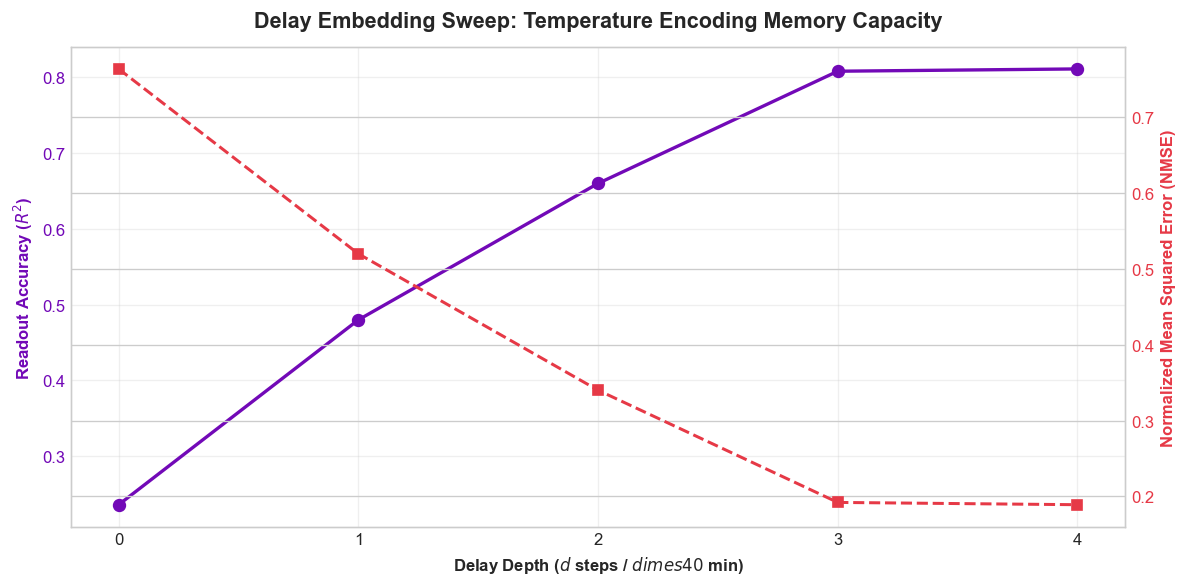

In [8]:
delays = range(0, 5)
sweep_rows = []

for d in delays:
    Xd, yd = delay_embed(X_hp, u_target, d)
    yp, nmse, mae, r2, m, sc, alpha = ridge_loo(Xd, yd)
    sweep_rows.append({
        'delay': d,
        'memory_min': d * CYCLE_MIN,
        'features': Xd.shape[1],
        'nmse': nmse,
        'r2': r2,
        'mae': mae,
        'alpha': alpha
    })

df_sweep = pd.DataFrame(sweep_rows)

fig, ax1 = plt.subplots(figsize=(10, 5))
color = '#7209b7'
ax1.set_xlabel('Delay Depth ($d$ steps / $d \times 40$ min)', fontweight='bold')
ax1.set_ylabel('Readout Accuracy ($R^2$)', color=color, fontweight='bold')
ax1.plot(df_sweep['delay'], df_sweep['r2'], color=color, marker='o', lw=2.0, ms=7, label='$R^2$')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(delays)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = '#e63946'
ax2.set_ylabel('Normalized Mean Squared Error (NMSE)', color=color, fontweight='bold')
ax2.plot(df_sweep['delay'], df_sweep['nmse'], color=color, marker='s', lw=1.8, ls='--', ms=6, label='NMSE')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Delay Embedding Sweep: Temperature Encoding Memory Capacity', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
sweep_plot_path = os.path.join(OUT_DIR, "delay_embedding_sweep.png")
plt.savefig(sweep_plot_path, dpi=150)
print(f"Saved delay sweep plot to: {sweep_plot_path}")
plt.show()

## Section 8 — Historical Memory vs Future Prediction Horizon

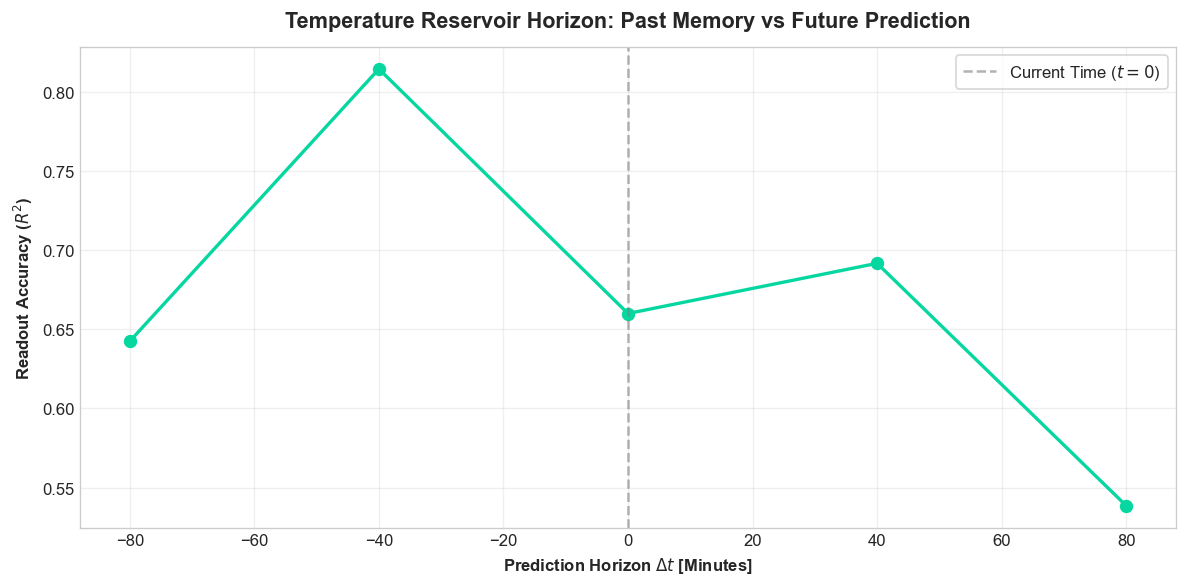

In [9]:
Xd, yd_base = delay_embed(X_hp, u_target, 2)
horizon_results = []

for k in [-2, -1, 0, 1, 2]:
    if k >= 0:
        X_sub = Xd[:len(Xd) - k] if k > 0 else Xd
        y_sub = u_target[2 + k:]
    else:
        shift = abs(k)
        X_sub = Xd[shift:]
        y_sub = u_target[2:len(u_target) - shift]
    
    yp_k, nmse_k, mae_k, r2_k, m_k, sc_k, a_k = ridge_loo(X_sub, y_sub)
    horizon_results.append({
        'horizon_steps': k,
        'horizon_min': k * 40,
        'nmse': nmse_k,
        'r2': r2_k,
        'mae': mae_k
    })

df_horizon = pd.DataFrame(horizon_results)

plt.figure(figsize=(10, 5))
plt.plot(df_horizon['horizon_min'], df_horizon['r2'], marker='o', color='#06d6a0', lw=2.0, ms=7)
plt.axvline(0, color='gray', ls='--', alpha=0.6, label='Current Time ($t=0$)')
plt.title('Temperature Reservoir Horizon: Past Memory vs Future Prediction', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Prediction Horizon $\Delta t$ [Minutes]', fontweight='bold')
plt.ylabel('Readout Accuracy ($R^2$)', fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 9 — Phase Lag & Cross-Correlation Analysis

In [10]:
print(f"{'Sensor':<18}  {'Max Cross-Corr':>14}  {'Optimal Lag (min)':>18}  {'Lead/Lag Status'}")
print("-" * 72)

for name in sensor_names:
    sig = df_hp[name].values
    lags = np.arange(-4, 5)
    corrs = []
    for lag in lags:
        if lag < 0:
            c = np.corrcoef(sig[:lag], u_target[-lag:])[0, 1]
        elif lag > 0:
            c = np.corrcoef(sig[lag:], u_target[:-lag])[0, 1]
        else:
            c = np.corrcoef(sig, u_target)[0, 1]
        corrs.append(c)
    
    best_lag_idx = np.argmax(np.abs(corrs))
    best_lag = lags[best_lag_idx]
    best_corr = corrs[best_lag_idx]
    lag_min = best_lag * 40
    
    if best_lag > 0:
        status = f"Lags target by +{lag_min} min (Thermal/Biophysical Delay)"
    elif best_lag < 0:
        status = f"Leads target by {lag_min} min"
    else:
        status = "In phase (0 min)"
    
    print(f"{name:<18}  {best_corr:>14.4f}  {lag_min:>18d}  {status}")

Sensor              Max Cross-Corr   Optimal Lag (min)  Lead/Lag Status
------------------------------------------------------------------------
measured_temp_c            -0.7222                 120  Lags target by +120 min (Thermal/Biophysical Delay)
OD_45                       0.5623                 -40  Leads target by -40 min
OD_90                       0.6092                -160  Leads target by -160 min
OD_135                     -0.6532                 -40  Leads target by -40 min
nm_415                     -0.7609                 -40  Leads target by -40 min
nm_445                     -0.7461                 -40  Leads target by -40 min
nm_480                     -0.7437                 -40  Leads target by -40 min
nm_515                     -0.7765                 -40  Leads target by -40 min
nm_555                     -0.7786                 -40  Leads target by -40 min
nm_590                     -0.7760                 -40  Leads target by -40 min
nm_630                    

## Section 10 — Predicted vs Actual Temperature Sine Wave Reconstruction Plot

Saved reconstruction plot to : data/sine wave encoding/temperature\results\reconstructed_sine_wave.png
Saved prediction table to   : data/sine wave encoding/temperature\results\readout_predictions.csv


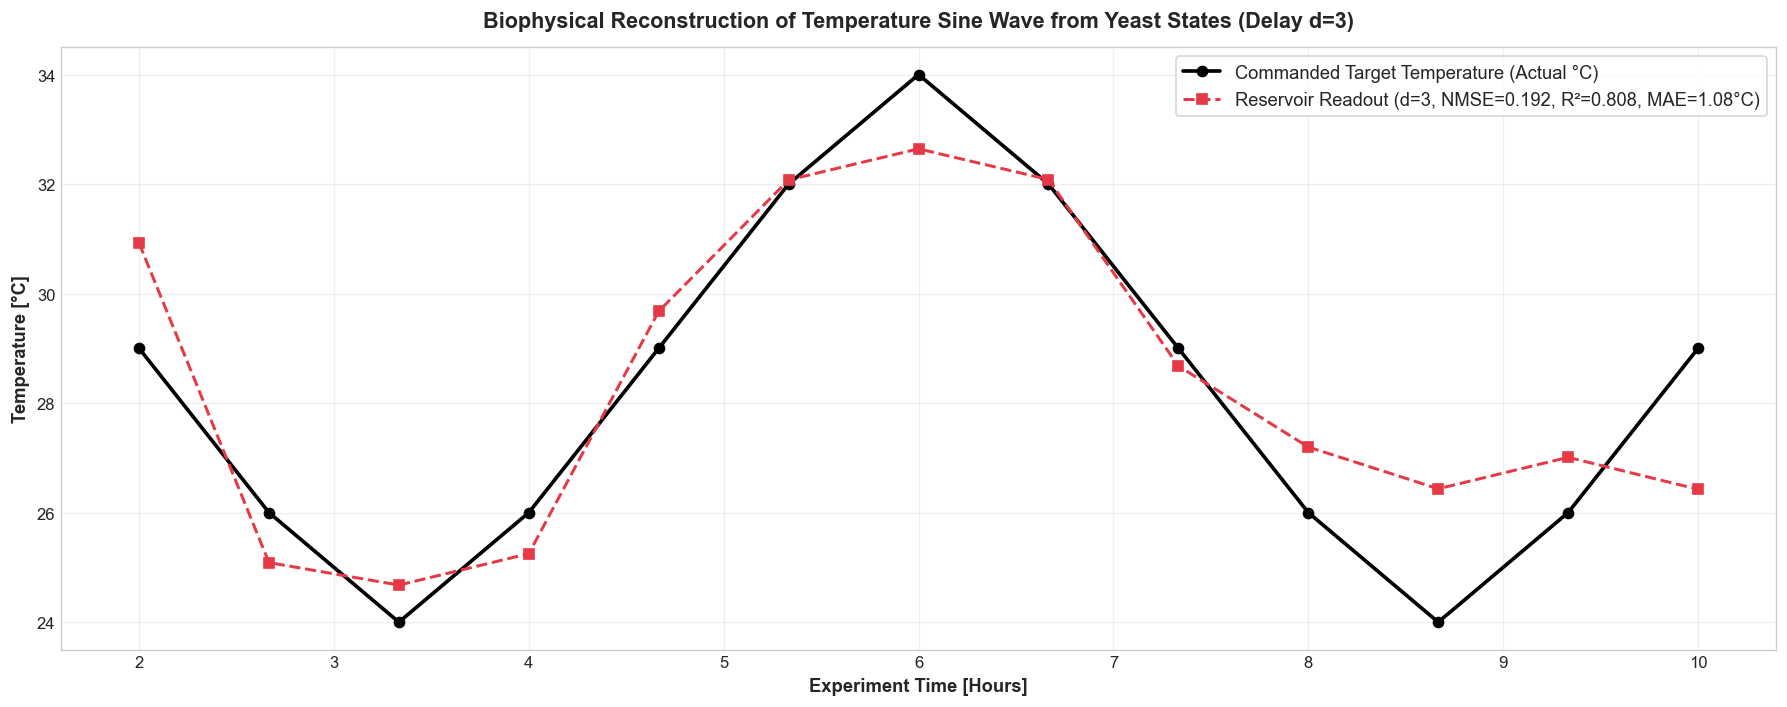

In [11]:
best_d = 3
Xd_best, yd_best = delay_embed(X_hp, u_target, best_d)
yp_best, nmse_b, mae_b, r2_b, m_b, sc_b, a_b = ridge_loo(Xd_best, yd_best)

cycles_idx = np.arange(best_d + 1, len(u_target) + 1)
time_hrs = (cycles_idx - 1) * (CYCLE_MIN / 60.0)

plt.figure(figsize=(15, 6))
plt.plot(time_hrs, yd_best, label='Commanded Target Temperature (Actual °C)', color='#000000', lw=2.2, marker='o', ms=6)
plt.plot(time_hrs, yp_best, label=f'Reservoir Readout (d={best_d}, NMSE={nmse_b:.3f}, R²={r2_b:.3f}, MAE={mae_b:.2f}°C)', color='#e63946', lw=1.8, ls='--', marker='s', ms=6)

plt.title(f'Biophysical Reconstruction of Temperature Sine Wave from Yeast States (Delay d={best_d})', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Experiment Time [Hours]', fontweight='bold', fontsize=11)
plt.ylabel('Temperature [°C]', fontweight='bold', fontsize=11)
plt.legend(loc='upper right', frameon=True, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

recon_plot_path = os.path.join(OUT_DIR, "reconstructed_sine_wave.png")
plt.savefig(recon_plot_path, dpi=150)

df_pred_exp = pd.DataFrame({
    'cycle': cycles_idx,
    'time_hours': time_hrs,
    'target_temperature_c': yd_best,
    'predicted_temperature_c': yp_best
})
pred_csv_path = os.path.join(OUT_DIR, "readout_predictions.csv")
df_pred_exp.to_csv(pred_csv_path, index=False)
print(f"Saved reconstruction plot to : {recon_plot_path}")
print(f"Saved prediction table to   : {pred_csv_path}")
plt.show()